In [1]:
%pip install xgboost shap --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# CAMPUS PLACEMENT PREDICTION
# XGBoost + Random Forest + Cross Validation
# Hyperparameter Tuning + SHAP Explanation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [4]:
# ============================================================
# 1. LOAD DATASET
# ============================================================

file_path = "Placement_Data_Full_Class.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape: (215, 15)

First 5 Rows:
   sl_no gender  ssc_p    ssc_b  hsc_p    hsc_b     hsc_s  degree_p  \
0      1      M  67.00   Others  91.00   Others  Commerce     58.00   
1      2      M  79.33  Central  78.33   Others   Science     77.48   
2      3      M  65.00  Central  68.00  Central      Arts     64.00   
3      4      M  56.00  Central  52.00  Central   Science     52.00   
4      5      M  85.80  Central  73.60  Central  Commerce     73.30   

    degree_t workex  etest_p specialisation  mba_p      status    salary  
0   Sci&Tech     No     55.0         Mkt&HR  58.80      Placed  270000.0  
1   Sci&Tech    Yes     86.5        Mkt&Fin  66.28      Placed  200000.0  
2  Comm&Mgmt     No     75.0        Mkt&Fin  57.80      Placed  250000.0  
3   Sci&Tech     No     66.0         Mkt&HR  59.43  Not Placed       NaN  
4  Comm&Mgmt     No     96.8        Mkt&Fin  55.50      Placed  425000.0  


In [5]:
# ============================================================
# 2. BASIC INFORMATION
# ============================================================

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["status"].value_counts())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB
None

Missing Values:
sl_no              0
ge

In [6]:
# ============================================================
# 3. REMOVE UNNECESSARY COLUMNS
# ============================================================

# sl_no is only a serial number, so it is not useful
if "sl_no" in df.columns:
    df = df.drop(columns=["sl_no"])

# salary has many missing values for students who were not placed
# We don't need salary for predicting placement status
if "salary" in df.columns:
    df = df.drop(columns=["salary"])

In [7]:
# ============================================================
# 4. CONVERT TARGET INTO 0 AND 1
# ============================================================

df["status"] = df["status"].map({
    "Placed": 1,
    "Not Placed": 0
})

print("\nTarget after encoding:")
print(df["status"].value_counts())


Target after encoding:
status
1    148
0     67
Name: count, dtype: int64


In [8]:
# ============================================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["status"])
y = df["status"]


In [9]:
# ============================================================
# 6. ENCODE CATEGORICAL FEATURES
# ============================================================

X = pd.get_dummies(X, drop_first=True)

# Convert True/False into 1/0
X = X.astype(float)

In [10]:
# ============================================================
# 7. HANDLE MISSING VALUES
# ============================================================

X = X.fillna(X.median())

print("\nProcessed Features:")
print(X.head())

print("\nNumber of Features:", X.shape[1])


Processed Features:
   ssc_p  hsc_p  degree_p  etest_p  mba_p  gender_M  ssc_b_Others  \
0  67.00  91.00     58.00     55.0  58.80       1.0           1.0   
1  79.33  78.33     77.48     86.5  66.28       1.0           0.0   
2  65.00  68.00     64.00     75.0  57.80       1.0           0.0   
3  56.00  52.00     52.00     66.0  59.43       1.0           0.0   
4  85.80  73.60     73.30     96.8  55.50       1.0           0.0   

   hsc_b_Others  hsc_s_Commerce  hsc_s_Science  degree_t_Others  \
0           1.0             1.0            0.0              0.0   
1           1.0             0.0            1.0              0.0   
2           0.0             0.0            0.0              0.0   
3           0.0             0.0            1.0              0.0   
4           0.0             1.0            0.0              0.0   

   degree_t_Sci&Tech  workex_Yes  specialisation_Mkt&HR  
0                1.0         0.0                    1.0  
1                1.0         1.0             

In [11]:
# ============================================================
# 8. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)


Training Data: (172, 14)
Testing Data : (43, 14)


In [12]:
# ============================================================
# 9. RANDOM FOREST BASELINE
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n================================")
print("RANDOM FOREST RESULTS")
print("================================")

print("Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


RANDOM FOREST RESULTS
Accuracy: 0.8837209302325582

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.69      0.78        13
           1       0.88      0.97      0.92        30

    accuracy                           0.88        43
   macro avg       0.89      0.83      0.85        43
weighted avg       0.89      0.88      0.88        43



In [13]:
# ============================================================
# 10. XGBOOST BASELINE
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("\n================================")
print("XGBOOST RESULTS")
print("================================")

print("Accuracy:", xgb_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))


XGBOOST RESULTS
Accuracy: 0.8372093023255814

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.62      0.70        13
           1       0.85      0.93      0.89        30

    accuracy                           0.84        43
   macro avg       0.82      0.77      0.79        43
weighted avg       0.83      0.84      0.83        43



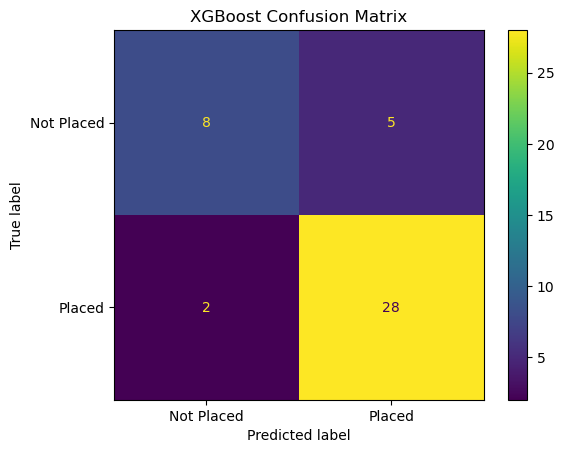

In [14]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [15]:
# ============================================================
# 12. ROC-AUC
# ============================================================

xgb_probability = xgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, xgb_probability)

print("\nROC-AUC Score:", auc)


ROC-AUC Score: 0.917948717948718


In [16]:
# ============================================================
# 13. STRATIFIED 5-FOLD CROSS VALIDATION
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=skf,
    scoring="accuracy"
)

print("\n================================")
print("5-FOLD CROSS VALIDATION")
print("================================")

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i} Accuracy: {score:.4f}")

print("Mean CV Accuracy:", cv_scores.mean())


5-FOLD CROSS VALIDATION
Fold 1 Accuracy: 0.8372
Fold 2 Accuracy: 0.9070
Fold 3 Accuracy: 0.9302
Fold 4 Accuracy: 0.8605
Fold 5 Accuracy: 0.9070
Mean CV Accuracy: 0.8883720930232558


In [17]:
# ============================================================
# 14. HYPERPARAMETER TUNING
# ============================================================

param_grid = {

    "n_estimators": [100, 200, 300, 500],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

search = RandomizedSearchCV(

    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ),

    param_distributions=param_grid,

    n_iter=20,

    scoring="accuracy",

    cv=3,

    random_state=42,

    n_jobs=-1,

    verbose=1
)

search.fit(X_train, y_train)

print("\n================================")
print("BEST PARAMETERS")
print("================================")

print(search.best_params_)

print("\nBest CV Accuracy:")
print(search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

BEST PARAMETERS
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

Best CV Accuracy:
0.8487598306110103


In [18]:
# ============================================================
# 15. BEST XGBOOST MODEL
# ============================================================

best_model = search.best_estimator_

best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)

best_probability = best_model.predict_proba(X_test)[:, 1]


In [19]:
# ============================================================
# 16. FINAL RESULTS
# ============================================================

final_accuracy = accuracy_score(
    y_test,
    best_pred
)

final_auc = roc_auc_score(
    y_test,
    best_probability
)

print("\n================================")
print("FINAL XGBOOST RESULTS")
print("================================")

print("Accuracy :", final_accuracy)
print("ROC-AUC  :", final_auc)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_pred,
        target_names=["Not Placed", "Placed"]
    )
)


FINAL XGBOOST RESULTS
Accuracy : 0.813953488372093
ROC-AUC  : 0.9051282051282051

Classification Report:
              precision    recall  f1-score   support

  Not Placed       0.73      0.62      0.67        13
      Placed       0.84      0.90      0.87        30

    accuracy                           0.81        43
   macro avg       0.79      0.76      0.77        43
weighted avg       0.81      0.81      0.81        43



In [20]:
# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n================================")
print("TOP 15 IMPORTANT FEATURES")
print("================================")

print(importance.head(15))


TOP 15 IMPORTANT FEATURES
ssc_p                    0.210475
degree_p                 0.135545
hsc_p                    0.119344
workex_Yes               0.080075
specialisation_Mkt&HR    0.075543
gender_M                 0.060081
ssc_b_Others             0.057400
mba_p                    0.056904
hsc_s_Commerce           0.053834
hsc_b_Others             0.046958
hsc_s_Science            0.037906
etest_p                  0.034412
degree_t_Sci&Tech        0.031522
degree_t_Others          0.000000
dtype: float32


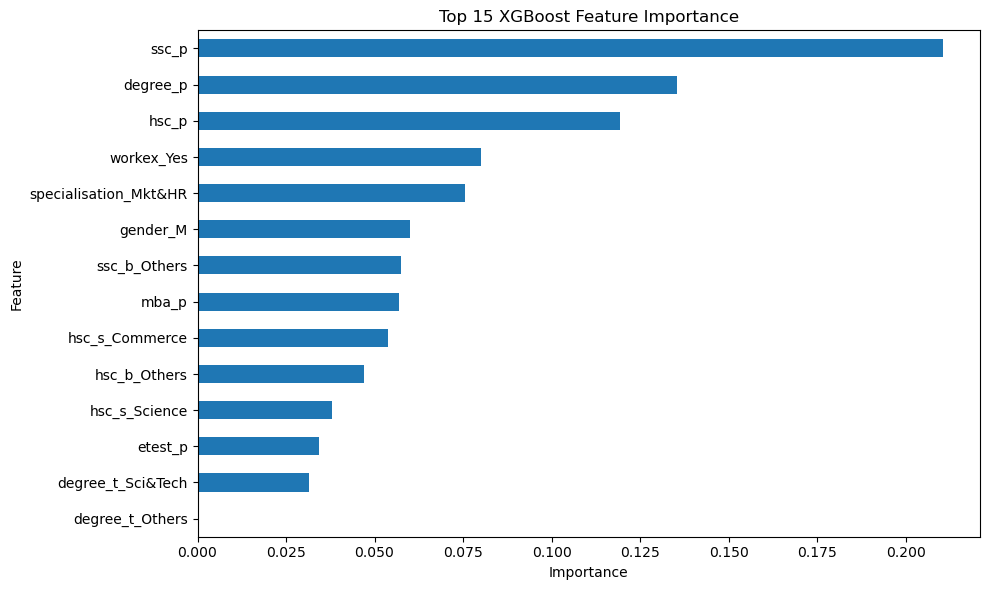

In [21]:
# ============================================================
# 18. FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top 15 XGBoost Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [22]:
# ============================================================
# 19. SHAP EXPLANATION
# ============================================================

print("\nCalculating SHAP values...")

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)


Calculating SHAP values...


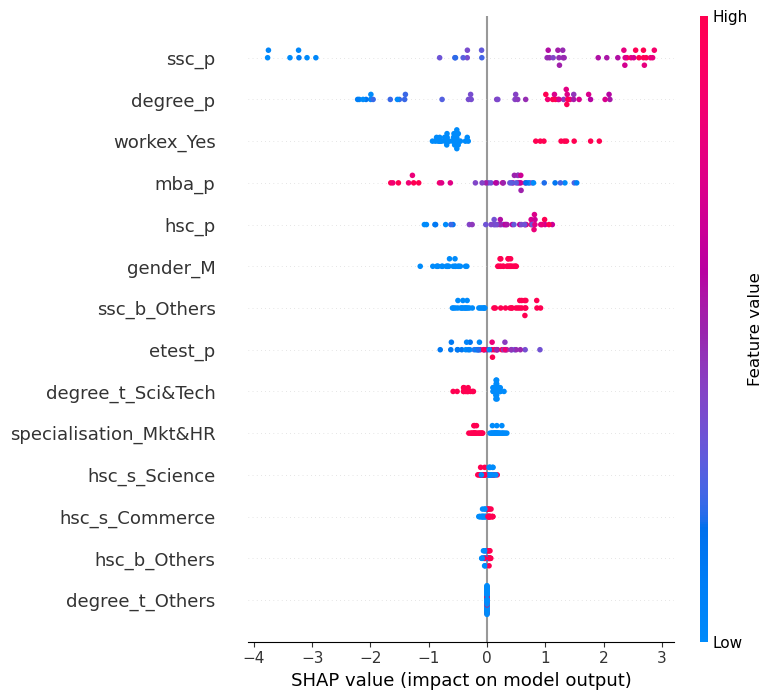

In [23]:
# ============================================================
# 20. SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test
)

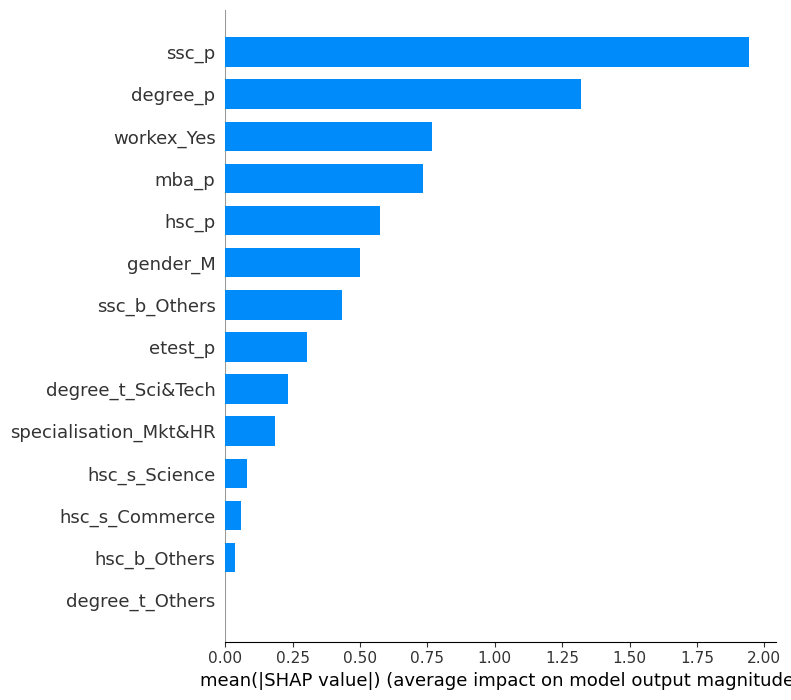

In [24]:

# ============================================================
# 21. SHAP BAR PLOT
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


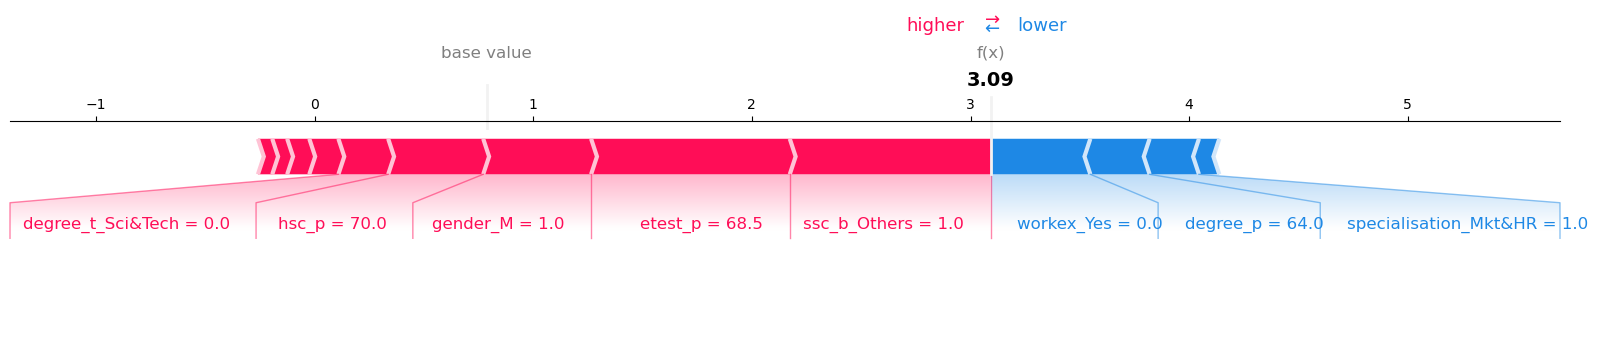

In [25]:
# ============================================================
# 22. EXPLAIN ONE STUDENT
# ============================================================

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)

plt.show()


In [26]:
# ============================================================
# 23. FINAL SUMMARY
# ============================================================

print("\n============================================")
print("       CAMPUS PLACEMENT PROJECT")
print("============================================")

print("Random Forest Accuracy :", rf_accuracy)

print("XGBoost Accuracy       :", xgb_accuracy)

print("Tuned XGBoost Accuracy :", final_accuracy)

print("ROC-AUC Score           :", final_auc)

print("Mean CV Accuracy        :", cv_scores.mean())

print("\nTop 5 Important Features:")

print(importance.head(5))



       CAMPUS PLACEMENT PROJECT
Random Forest Accuracy : 0.8837209302325582
XGBoost Accuracy       : 0.8372093023255814
Tuned XGBoost Accuracy : 0.813953488372093
ROC-AUC Score           : 0.9051282051282051
Mean CV Accuracy        : 0.8883720930232558

Top 5 Important Features:
ssc_p                    0.210475
degree_p                 0.135545
hsc_p                    0.119344
workex_Yes               0.080075
specialisation_Mkt&HR    0.075543
dtype: float32
